# jove.nvim feature tour

This notebook demonstrates what `jove.nvim` can do. Open it in Neovim, 
run `:checkhealth jove` once to verify your setup, then walk the cells 
top to bottom.

- **Cell navigation**: jump between cells with `[c` / `]c`, or use
  `:Jove next-cell` / `:Jove prev-cell`.
- **Sidebar**: `:Jove sidebar` opens the variables inspector, kernel info,
  and a table of contents built from the Markdown headings below.
- **Running cells**: `:Jove run-cell` runs the cell under the cursor,
  `:Jove run-above` / `:Jove run-all` run more. Watch the gutter signs
  (`…` queued, `▶` running, `✓` ok, `✗` error) and the per-cell execution
  count and elapsed time in the cell header.
- **Round-tripping**: save with `:w` and the outputs plus execution counts
  are merged back into this `.ipynb` file.

## 1. Text output

Stream output (`print`) and expression results render inline, right under
the cell. `:Jove toggle-output` hides them, `:Jove open-output` opens them
in a dedicated window, and `:Jove clear-output` clears them.

In [1]:
greeting = "Hello from the jove kernel"
print(greeting)
print("stream output is captured live, line by line")

Hello from the jove kernel
stream output is captured live, line by line


In [2]:
squares = {n: n * n for n in range(6)}
squares

{0: 0, 1: 1, 2: 4, 3: 9, 4: 16, 5: 25}

## 2. Rich text and tables

MIME bundles render with the richest text representation available.

In [3]:
import pandas as pd

df = pd.DataFrame(
    {
        "language": ["Python", "Julia", "R", "JavaScript", "TypeScript"],
        "cell marker": ["# %%", "# %%", "# %%", "// %%", "// %%"],
        "lsp": ["pyright", "julials", "r_language_server", "ts_ls", "ts_ls"],
    }
)
df

,language,cell marker,lsp
0,Python,# %%,pyright
1,Julia,# %%,julials
2,R,# %%,r_language_server
3,JavaScript,// %%,ts_ls
4,TypeScript,// %%,ts_ls


## 3. ANSI colors

Terminal escape sequences in stream output are rendered as real highlight
groups. 

In [4]:
print("\x1b[32m\u2713 green check\x1b[0m  \x1b[31m\u2717 red cross\x1b[0m  \x1b[1m\x1b[34mbold blue\x1b[0m")
print("\x1b[38;5;208m256-color orange\x1b[0m and \x1b[48;5;235m\x1b[37mgray background\x1b[0m")

✓ green check  ✗ red cross  bold blue
256-color orange and gray background


## 4. Errors and interrupting

Tracebacks render stripped of ANSI codes with the error sign in the gutter.
The long-running cell below is a good target for `:Jove interrupt`,
`:Jove goto-running-cell`, and `:Jove toggle-follow-running`.

In [ ]:
def boom():
    return 1 / 0

boom()

In [ ]:
import time

for i in range(30):
    print(f"tick {i}", flush=True)
    time.sleep(1)

## 5. Running a selection

Visually select either of the lines below and run `:Jove run-selection`
(or `<Plug>(JoveRunSelection)`). 

In [ ]:
answer = 6 * 7
answer

## 6. HTML and the webview

HTML output renders inline as plain text. With `webview.enabled` and the
`terminal-browser` binary installed, `:Jove open-webview` shows the real
HTML interactively in a floating terminal, including JavaScript-driven
pages like interactive Plotly charts. Hover for tooltips, zoom and pan,
and press play on the animation below.

In [5]:
import plotly.express as px

df = px.data.gapminder()
fig = px.scatter(
    df,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    animation_frame="year",
    animation_group="country",
    hover_name="country",
    log_x=True,
    size_max=55,
    range_x=[100, 100000],
    range_y=[25, 90],
    title="Gapminder: life expectancy vs. GDP per capita (1952-2007)",
)
fig.show()

## 7. Images

With `snacks.nvim` installed and `output.images = true`, plots render
inline in the terminal. Without it, the text fallback is shown instead.

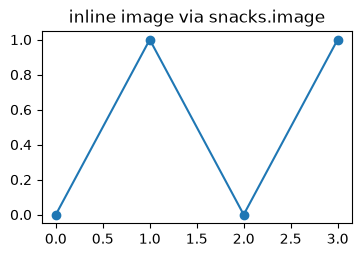

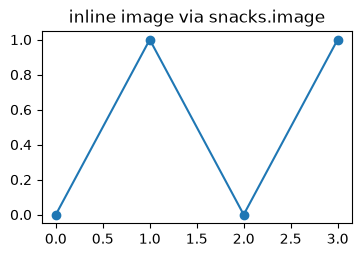

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot([0, 1, 2, 3], [0, 1, 0, 1], marker="o")
ax.set_title("inline image via snacks.image")
fig

## 8. Kernel management

- `:Jove select-kernel` picks another kernelspec.
- `:Jove restart-kernel` and `:Jove shutdown-kernel` manage the lifecycle.
- `:Jove reload` re-reads the notebook from disk (or enable
  `auto_reload`).

In [ ]:
import sys

print(f"kernel python: {sys.version.split()[0]}")
print("open :Jove sidebar and press 2 for full kernel info")